In [ ]:
#Libraries 
import yfinance as yf
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib import rcParams
from matplotlib.ticker import PercentFormatter 
import numpy as np

#Download data from yahoo finance
Tickers = ["AAPL", "MSFT"]

data = yf.download(
    Tickers,
    start='2022-01-01',
    end='2026-01-01'
)

prices = data["Close"]

[*********************100%***********************]  2 of 2 completed


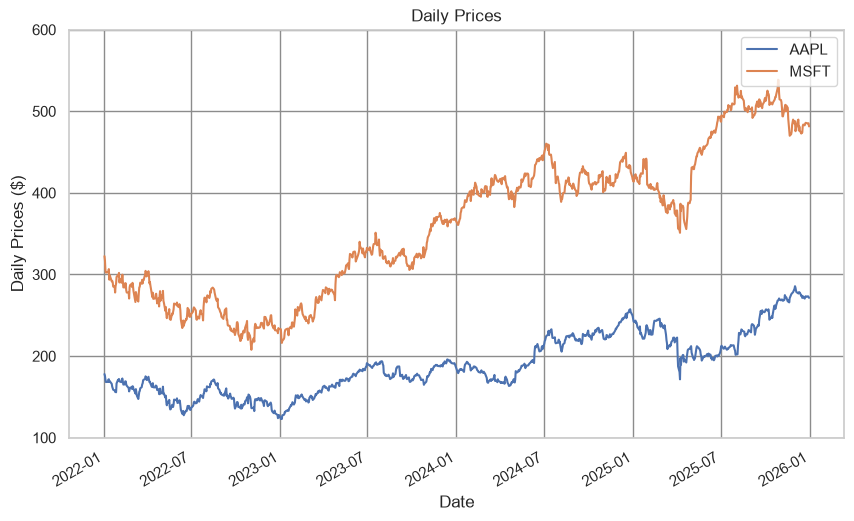

In [30]:
#Daily Price 
rcParams['figure.figsize'] = 10,6
prices.plot(kind='line')
plt.grid(True, color='C7')
plt.title("Daily Prices")
plt.xlabel("Date")
plt.ylabel("Daily Prices ($)")
plt.ylim(100, 600)
plt.legend(loc=1)
plt.show()

In [ ]:
# Returns
returns = prices.pct_change() * 100

In [94]:
returns = returns.dropna()

returns

Ticker,AAPL,MSFT
Date,,
2022-01-04,-1.269181,-1.714720
2022-01-05,-2.659958,-3.838776
2022-01-06,-1.669355,-0.790209
2022-01-07,0.098847,0.050981
2022-01-10,0.011631,0.073229
...,...,...
2025-12-24,0.532378,0.240310
2025-12-26,-0.149739,-0.063515
2025-12-29,0.131691,-0.125075


In [21]:
# Set Index 
returns_in = returns.reset_index()

returns_long = returns_in.melt(
    id_vars='Date',
    var_name='Ticker',
    value_name='Returns'
)

returns_long


,Date,Ticker,Returns
0,2022-01-04,AAPL,-1.269181
1,2022-01-05,AAPL,-2.659958
2,2022-01-06,AAPL,-1.669355
3,2022-01-07,AAPL,0.098847
4,2022-01-10,AAPL,0.011631
...,...,...,...
1999,2025-12-24,MSFT,0.240310
2000,2025-12-26,MSFT,-0.063515
2001,2025-12-29,MSFT,-0.125075
2002,2025-12-30,MSFT,0.078015


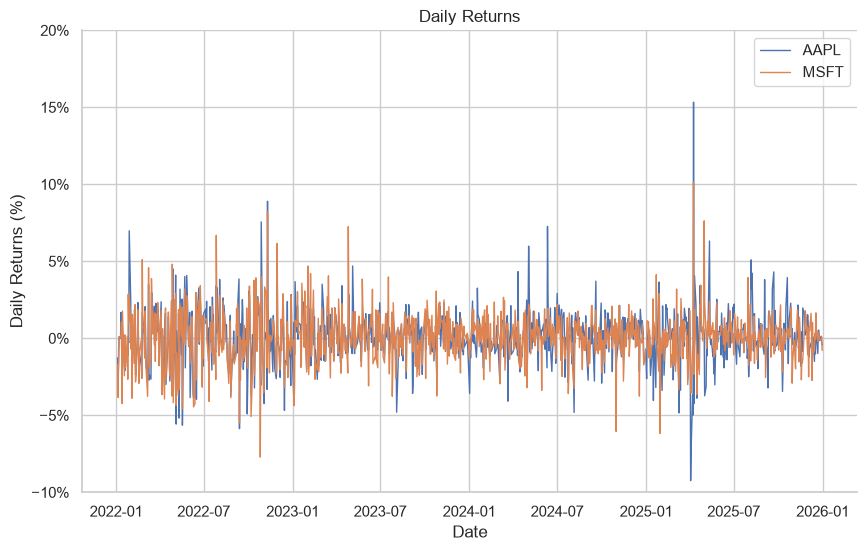

In [28]:
# Plot Daily Returns 
sns.lineplot(data=returns_long, x='Date', y='Returns', hue='Ticker', linewidth=1)
sns.set_theme(style='whitegrid')
sns.despine()

# yFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

#Adjustments
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Returns (%)")
plt.ylim(-10, 20)
plt.legend(loc=1)
plt.show()


In [37]:
tickers_rets = returns_long['Ticker'].unique().tolist()

tickers_rets

['AAPL', 'MSFT']

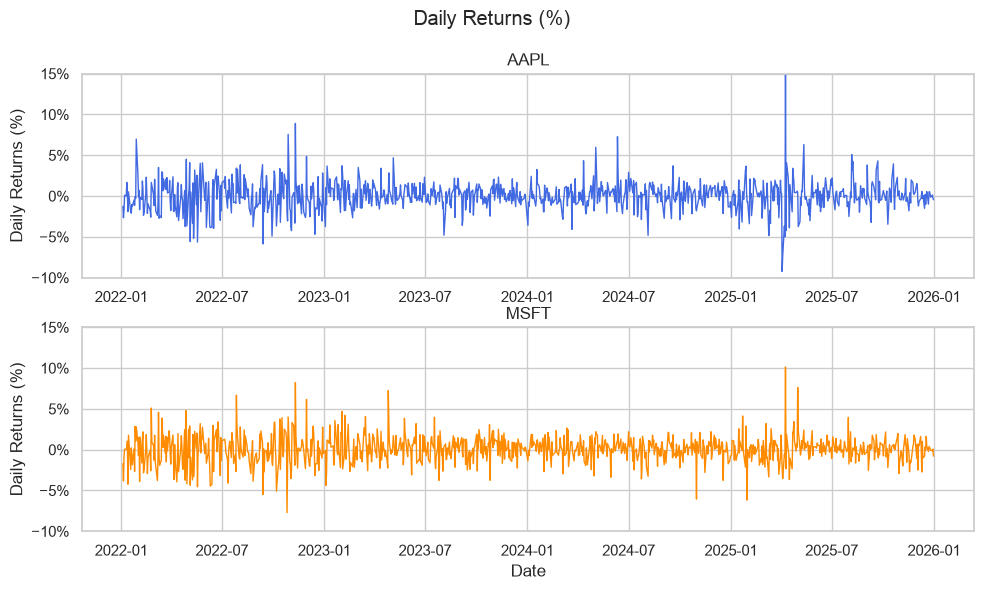

In [77]:
colors = ['royalblue', 'darkorange']   

fig, ax = plt.subplots(len(tickers_rets), 1)

for i, ticker_ret in enumerate(tickers_rets):
    ticker_plot = returns_long[returns_long['Ticker'] == ticker_ret]
    sns.lineplot(data=ticker_plot, x='Date', y='Returns', ax=ax[i], color=colors[i], linewidth=1)

    ax[i].set_title(ticker_ret)
    ax[i].set_ylabel('Daily Returns (%)')
    ax[i].set_ylim(-10, 15)
    if i == 0:                 # First graph only
        ax[i].set_xlabel('')


# yFormatter
for i, ticker_ret in enumerate(tickers_rets):
    ax[i].yaxis.set_major_formatter(PercentFormatter(decimals=0))

fig.suptitle('Daily Returns (%)')
fig.tight_layout(h_pad=0.1)
plt.show()

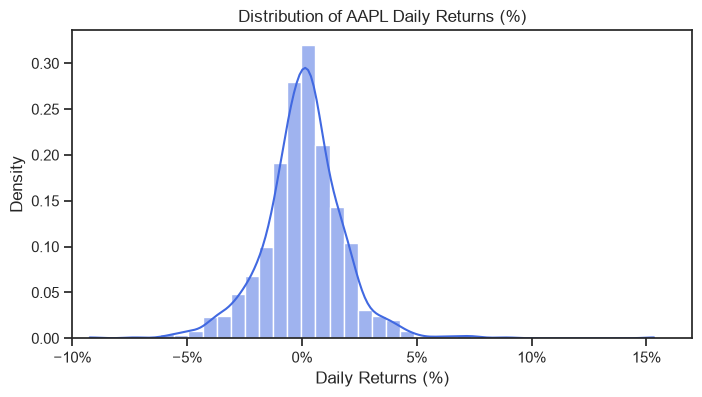

In [213]:
#Histogram plot 
aapl_returns = returns_long[returns_long['Ticker'] == 'AAPL']

plt.figure(figsize = (8, 4))

sns.histplot(data=aapl_returns, x='Returns', stat='density', kde=True, bins=40, color='royalblue')
plt.title('Distribution of AAPL Daily Returns (%)')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Density')
plt.xlim(-10, 17)
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.show()

In [103]:
aapl_returns 

,Date,Ticker,Returns
0,2022-01-04,AAPL,-1.269181
1,2022-01-05,AAPL,-2.659958
2,2022-01-06,AAPL,-1.669355
3,2022-01-07,AAPL,0.098847
4,2022-01-10,AAPL,0.011631
...,...,...,...
997,2025-12-24,AAPL,0.532378
998,2025-12-26,AAPL,-0.149739
999,2025-12-29,AAPL,0.131691
1000,2025-12-30,AAPL,-0.248405


In [124]:
msft_returns = returns_long[returns_long['Ticker'] == 'MSFT']

msft_returns

,Date,Ticker,Returns
1002,2022-01-04,MSFT,-1.714720
1003,2022-01-05,MSFT,-3.838776
1004,2022-01-06,MSFT,-0.790209
1005,2022-01-07,MSFT,0.050981
1006,2022-01-10,MSFT,0.073229
...,...,...,...
1999,2025-12-24,MSFT,0.240310
2000,2025-12-26,MSFT,-0.063515
2001,2025-12-29,MSFT,-0.125075
2002,2025-12-30,MSFT,0.078015


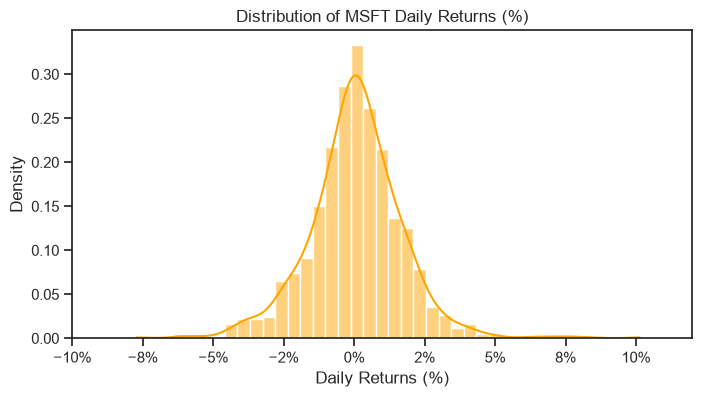

In [212]:
#Histogram plot 
plt.figure(figsize = (8, 4))

sns.histplot(data=msft_returns, x='Returns', stat='density', kde=True, bins=40, color='orange')
plt.title('Distribution of MSFT Daily Returns (%)')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Density')
plt.xlim(-10, 12)
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.show() 




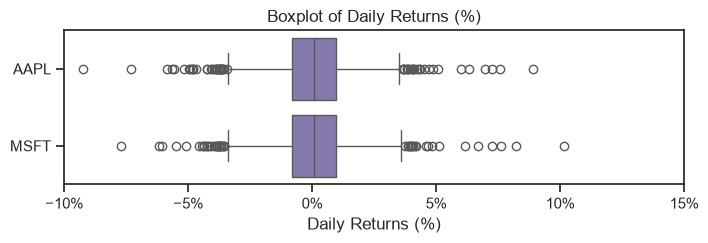

In [214]:
# Boxplot
sns.set_theme(style='ticks')

plt.figure(figsize = (8, 2))

sns.boxplot(data=returns_long, x='Returns', y='Ticker', color='m') 

plt.title('Boxplot of Daily Returns (%)')
plt.xlabel('Daily Returns (%)')
plt.ylabel('')
plt.xlim(-10, 15)
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.show() 

In [163]:
rolling_vol = (
    returns_long
    .groupby('Ticker')['Returns']
    .rolling(window=21)
    .std()
    .reset_index(level=0, drop=True)
)

In [ ]:
# Create a column name Rolling Volatility 
returns_long['RollingVolatility'] = rolling_vol

In [176]:
returns_long

,Date,Ticker,Returns,RollingVolatility
0,2022-01-04,AAPL,-1.269181,NaN
1,2022-01-05,AAPL,-2.659958,NaN
2,2022-01-06,AAPL,-1.669355,NaN
3,2022-01-07,AAPL,0.098847,NaN
4,2022-01-10,AAPL,0.011631,NaN
...,...,...,...,...
1999,2025-12-24,MSFT,0.240310,1.216159
2000,2025-12-26,MSFT,-0.063515,1.211750
2001,2025-12-29,MSFT,-0.125075,1.150152
2002,2025-12-30,MSFT,0.078015,1.110061


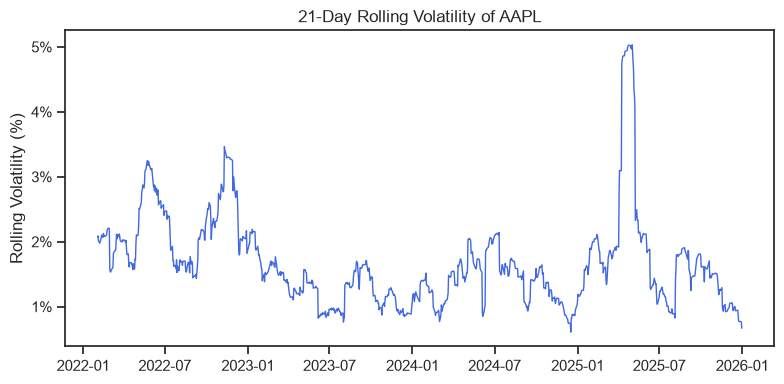

In [206]:
# Plot Rolling Volatility for AAPL
aapl_vol = returns_long[returns_long['Ticker']== 'AAPL']

plt.figure(figsize = (8, 4))
# Plot the graph 
sns.lineplot(
    data=aapl_vol,
    x='Date',
    y='RollingVolatility',
    color='royalblue',
    linewidth=1
)

# Plot the graph
plt.title('21-Day Rolling Volatility of AAPL')
plt.xlabel('')
plt.ylabel('Rolling Volatility (%)')

# yFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjustments
plt.tight_layout()
plt.show()

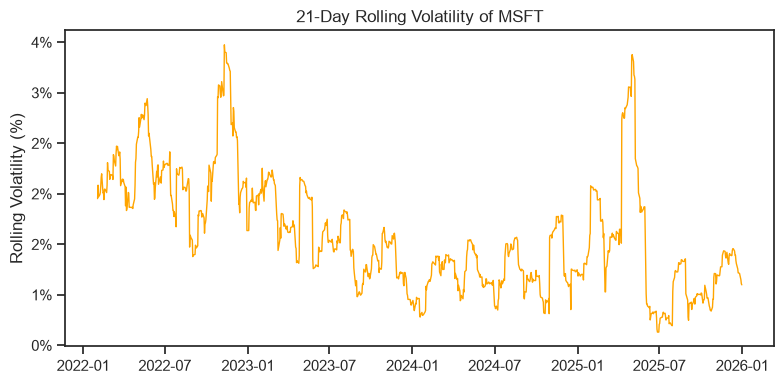

In [205]:
# Plot Rolling Volatility for MSFT
msft_vol = returns_long[returns_long['Ticker']== 'MSFT']

plt.figure(figsize = (8, 4))
# Plot the graph 
sns.lineplot(
    data=msft_vol,
    x='Date',
    y='RollingVolatility',
    color='orange',
    linewidth=1
)

# Plot the graph
plt.title('21-Day Rolling Volatility of MSFT')
plt.xlabel('')
plt.ylabel('Rolling Volatility (%)')

# yFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjustments
plt.tight_layout()
plt.show()

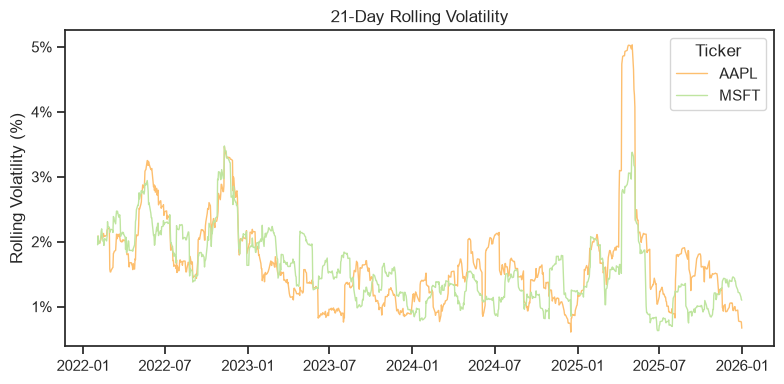

In [215]:
plt.figure(figsize = (8, 4))

# Plot the graph 
sns.lineplot(
    data=returns_long,
    x='Date',
    y='RollingVolatility',
    hue='Ticker',
    palette='Spectral',
    linewidth=1
)

# Plot the graph
plt.title('21-Day Rolling Volatility')
plt.xlabel('')
plt.ylabel('Rolling Volatility (%)')

# yFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjustments
plt.tight_layout()
plt.show()

In [218]:
aapl_prices = prices['AAPL']

In [219]:
#Drawdown AAPL

running_max = aapl_prices.cummax()
drawdown = (aapl_prices - running_max) / running_max

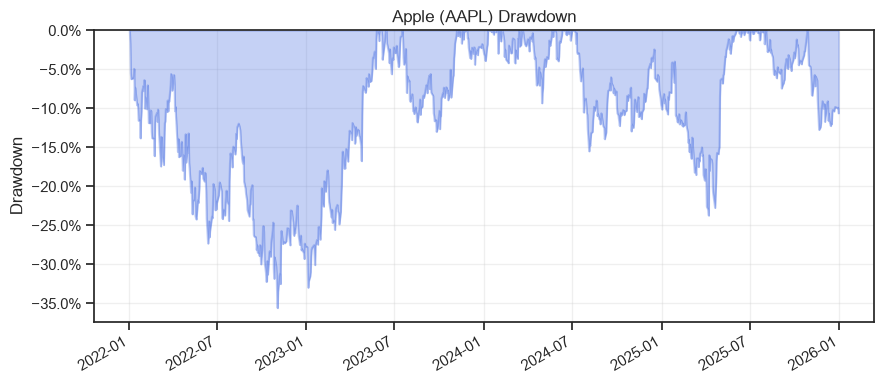

In [238]:
# Plot graph 

plt.figure(figsize = (9, 4))

drawdown.plot(
    kind='area',
    color='royalblue', 
    alpha=0.3
)

plt.title('Apple (AAPL) Drawdown')
plt.xlabel('')
plt.ylabel('Drawdown')

#yFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [229]:
msft_prices = prices['MSFT']

In [233]:
#Drawdown MSFT

running_max = msft_prices.cummax()
drawdown_msft = (msft_prices - running_max) / running_max

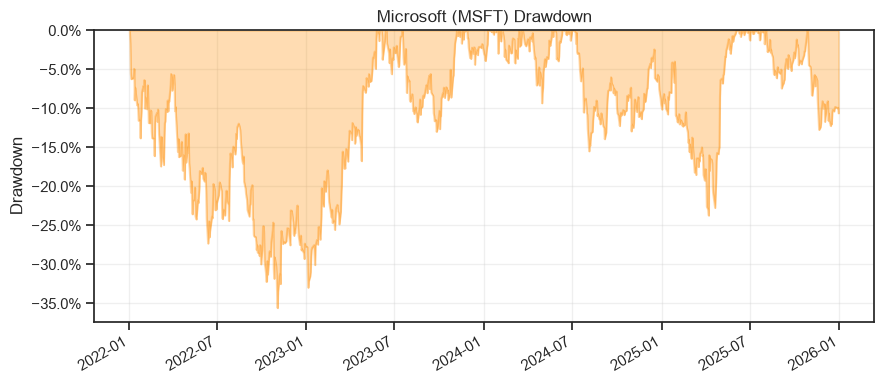

In [239]:
# Plot graph 

plt.figure(figsize = (9, 4))

drawdown_msft.plot(
    kind='area',
    color='darkorange', 
    alpha=0.3
)

plt.title('Microsoft (MSFT) Drawdown')
plt.xlabel('')
plt.ylabel('Drawdown')

#yFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()